In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

In [2]:
df = pd.read_csv('newborns_stats.csv')

In [3]:
df.isna().sum()

year      0
month     0
c1        2
cat1      0
target    0
dtype: int64

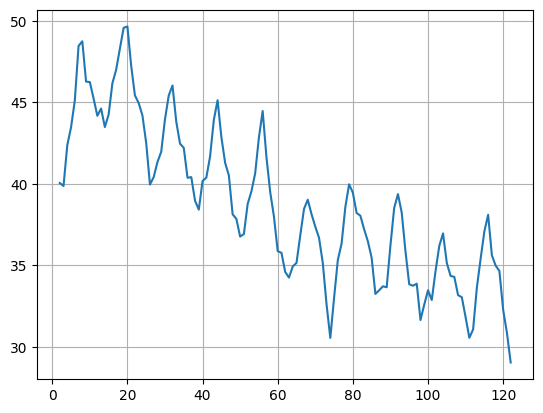

In [4]:
df['c1'].plot()
plt.grid()
plt.show()

In [5]:
df[['c1', 'cat1', 'target']].corr()

,c1,cat1,target
c1,1.000000,0.294024,0.883709
cat1,0.294024,1.000000,0.263559
target,0.883709,0.263559,1.000000


заполняем пропуски

In [6]:
first_valid = df['c1'].dropna().iloc[0]

df['c1'] = df['c1'].fillna(first_valid)

In [7]:
df['c1'].head(2)

0    40.045
1    40.045
Name: c1, dtype: float64

разбиваем датасет на обучающий и валидирующий

In [8]:
train = df.iloc[:-12]
val = df.iloc[-12:]

print(len(train))
print(len(val))

111
12


In [9]:
features = ['year', 'month', 'c1', 'cat1']

X_train = train[features]
y_train = train['target']

X_val = val[features]
y_val = val['target']

In [10]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_val)

mae = mean_absolute_error(y_val, pred_lr)
print(mae)

mape = mean_absolute_percentage_error(y_val, pred_lr)
print(f'{mape:.2%}')

731.4006773667643
8.07%


In [11]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_val)

mae = mean_absolute_error(y_val, pred_rf)
print(mae)

mape = mean_absolute_percentage_error(y_val, pred_rf)
print(f'{mape:.2%}')

685.8858333333332
8.24%


In [12]:
pd.Series(
    lr.coef_,
    index=features
).sort_values(key=abs, ascending=False)

cat1     240.968820
year    -188.148672
c1       176.784367
month    -35.795845
dtype: float64

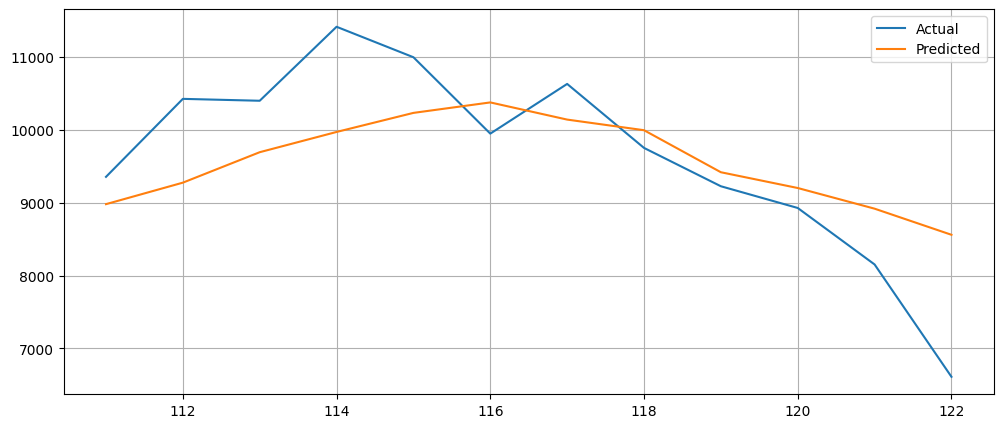

In [13]:
plt.figure(figsize=(12, 5))

plt.plot(val.index, y_val, label='Actual')
plt.plot(val.index, pred_lr, label='Predicted')

plt.legend()
plt.grid()
plt.show()

In [14]:
df['lag1'] = df['target'].shift(1)
df['lag12'] = df['target'].shift(12)

df = df.dropna().reset_index(drop=True)

train_new = df.iloc[:-12]
val_new = df.iloc[-12:]

In [15]:
features = ['year', 'month', 'c1', 'cat1', 'lag1', 'lag12']

X_train_new = train_new[features]
y_train_new = train_new['target']

X_val_new = val_new[features]
y_val_new = val_new['target']

In [16]:
lr = LinearRegression()
lr.fit(X_train_new, y_train_new)

pred_lr_new = lr.predict(X_val_new)

mae_new = mean_absolute_error(y_val_new, pred_lr_new)
print(mae_new)

mape_new = mean_absolute_percentage_error(y_val_new, pred_lr_new)
print(f'{mape_new:.2%}')

567.4243438068443
6.40%


In [17]:
df['cat1'].value_counts()

cat1
0    48
1    45
2    18
Name: count, dtype: int64

In [18]:
df_c1 = df.copy()

df_c1['lag1'] = df_c1['c1'].shift(1)
df_c1['lag12'] = df_c1['c1'].shift(12)

df_c1 = df_c1.dropna().reset_index(drop=True)

In [19]:
train_c1 = df_c1.iloc[:-12]
val_c1 = df_c1.iloc[-12:]

In [20]:
features_c1 = ['year', 'month', 'lag1', 'lag12']

X_train_c1 = train_c1[features_c1]
y_train_c1 = train_c1['c1']

X_val_c1 = val_c1[features_c1]
y_val_c1 = val_c1['c1']

In [21]:
model_c1 = LinearRegression()

model_c1.fit(X_train_c1, y_train_c1)

pred_c1 = model_c1.predict(X_val_c1)

In [22]:
lr.fit(X_train_c1, y_train_c1)

pred_lr_c1 = lr.predict(X_val_c1)

mae = mean_absolute_error(y_val_c1, pred_lr_c1)
print(mae)

mape_c1 = mean_absolute_percentage_error(y_val_c1, pred_lr_c1)
print(f'{mape_c1:.2%}')

1.2199537110080094
3.68%


In [23]:
model_c1.fit(
    df_c1[features_c1],
    df_c1['c1']
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [24]:
future_c1 = []

history = df['c1'].tolist()

last_year = df['year'].iloc[-1]
last_month = df['month'].iloc[-1]

In [25]:
for step in range(12):

    month = (last_month + step) % 12 + 1
    year = last_year + (last_month + step) // 12

    lag1 = history[-1]
    lag12 = history[-12]

    row = pd.DataFrame({
        'year': [year],
        'month': [month],
        'lag1': [lag1],
        'lag12': [lag12]
    })

    pred = model_c1.predict(row)[0]

    future_c1.append(pred)
    history.append(pred)

In [27]:
cat_history = df['cat1'].tolist()

future_cat1 = []

for _ in range(12):
    next_cat = cat_history[-15]
    future_cat1.append(next_cat)
    cat_history.append(next_cat)

In [28]:
df_target = df.copy()

df_target['lag1'] = df_target['target'].shift(1)
df_target['lag12'] = df_target['target'].shift(12)

df_target = df_target.dropna().reset_index(drop=True)

In [29]:
from sklearn.linear_model import LinearRegression

features_target = [
    'year',
    'month',
    'c1',
    'cat1',
    'lag1',
    'lag12'
]

X_full = df_target[features_target]
y_full = df_target['target']

lr_target = LinearRegression()
lr_target.fit(X_full, y_full)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [30]:
target_history = df['target'].tolist()

In [31]:
future_target = []

last_year = df['year'].iloc[-1]
last_month = df['month'].iloc[-1]

for step in range(12):

    month = (last_month + step) % 12 + 1
    year = last_year + (last_month + step) // 12

    lag1 = target_history[-1]
    lag12 = target_history[-12]

    row = pd.DataFrame({
        'year': [year],
        'month': [month],
        'c1': [future_c1[step]],
        'cat1': [future_cat1[step]],
        'lag1': [lag1],
        'lag12': [lag12]
    })

    pred = lr_target.predict(row)[0]

    future_target.append(pred)
    target_history.append(pred)

In [34]:
future_dates = []

year = df['year'].iloc[-1]
month = df['month'].iloc[-1]

for _ in range(12):

    month += 1

    if month > 12:
        month = 1
        year += 1

    future_dates.append((year, month))

In [36]:
forecast_df = pd.DataFrame({
    'year': [y for y, m in future_dates],
    'month': [m for y, m in future_dates],
    'predicted_target': future_target
})

forecast_df

,year,month,predicted_target
0,2025,4,8141.789563
1,2025,5,9346.517318
2,2025,6,9755.098826
3,2025,7,10473.885495
4,2025,8,10592.114727
5,2025,9,9980.880084
6,2025,10,10154.399269
7,2025,11,9703.183583
8,2025,12,9218.175410
9,2026,1,9095.813723


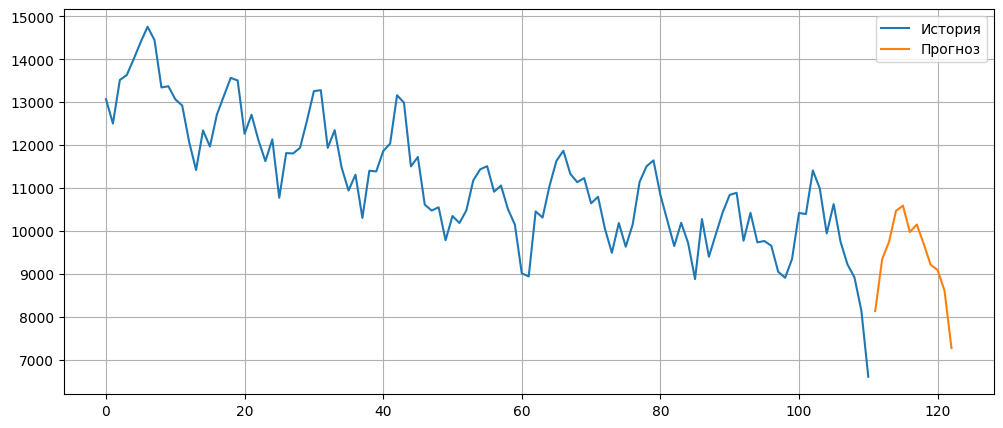

In [37]:
plt.figure(figsize=(12, 5))

plt.plot(df['target'], label='История')

future_index = range(len(df), len(df) + 12)

plt.plot(
    future_index,
    future_target,
    label='Прогноз'
)

plt.legend()
plt.grid()
plt.show()